In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from pathlib import Path
print('Ready.')

Ready.


In [ ]:

GOOD_IMAGE = '/kaggle/input/datasets/vidishagar/solder-spread/good.JPG'
BAD_IMAGE  = '/kaggle/input/datasets/vidishagar/solder-spread/defect.JPG'
OUTPUT_DIR = '/kaggle/working'

# Anchor region in GOOD image — stable component not affected by solder spread
# The axial resistor (coloured bands) at top works well here
# Format: y1, y2, x1, x2
ANCHOR_Y1, ANCHOR_Y2 = 10, 80
ANCHOR_X1, ANCHOR_X2 = 50, 380

# Region of interest in GOOD image — the area where solder spread can occur
ROI_X1, ROI_X2 = 130, 480
ROI_Y1, ROI_Y2 = 80,  320

# Detection thresholds
SSIM_THRESHOLD     = 0.50   # SSIM below this → DEFECTIVE
BRIGHT_THRESHOLD   = 40     # pixel brightness difference to count as extra solder
MIN_SOLDER_AREA    = 300    # minimum contour area (pixels²) to count as solder spread

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
print('Config loaded.')

Config loaded.


Good: 639x390
Bad : 768x473


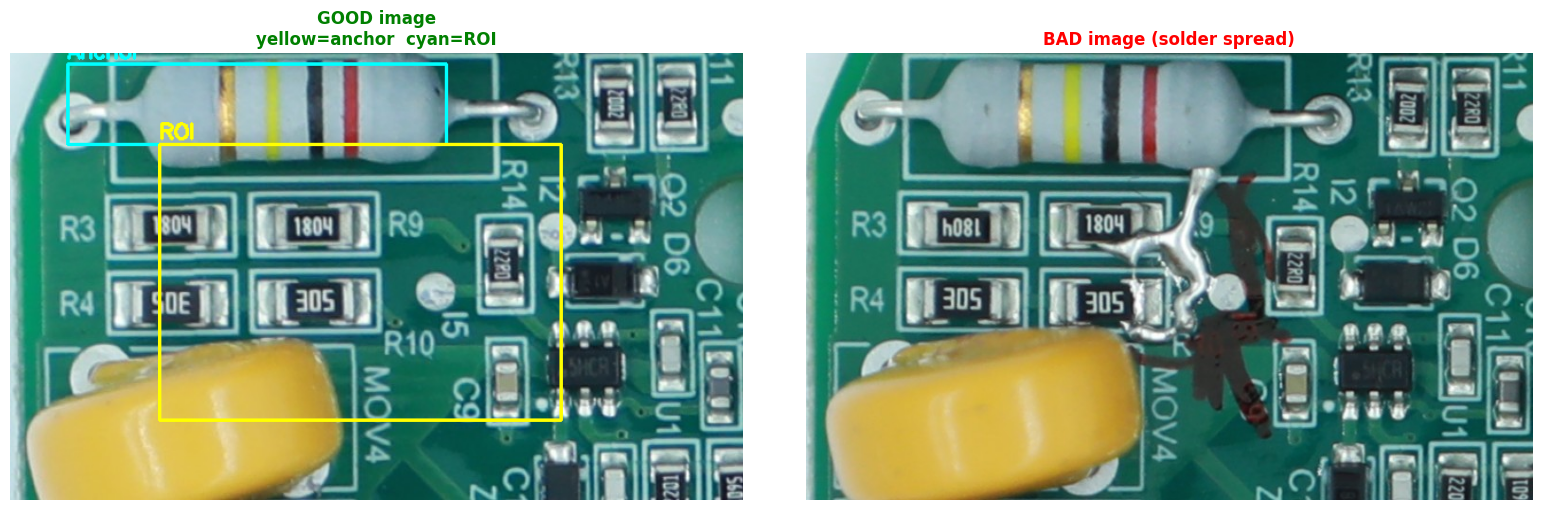

Verify: anchor (yellow) should be on a clean stable component.
        ROI (cyan) should cover the solder-prone area.


In [4]:
good = cv2.imread(GOOD_IMAGE)
bad  = cv2.imread(BAD_IMAGE)
assert good is not None, f'Cannot read: {GOOD_IMAGE}'
assert bad  is not None, f'Cannot read: {BAD_IMAGE}'
print(f'Good: {good.shape[1]}x{good.shape[0]}')
print(f'Bad : {bad.shape[1]}x{bad.shape[0]}')

fig, axes = plt.subplots(1,2,figsize=(16,5))
good_vis = good.copy()
# Draw anchor (cyan) and ROI (yellow) on good image
cv2.rectangle(good_vis,(ANCHOR_X1,ANCHOR_Y1),(ANCHOR_X2,ANCHOR_Y2),(255,255,0),2)
cv2.rectangle(good_vis,(ROI_X1,ROI_Y1),(ROI_X2,ROI_Y2),(0,255,255),2)
cv2.putText(good_vis,'Anchor',(ANCHOR_X1,ANCHOR_Y1-5),
            cv2.FONT_HERSHEY_SIMPLEX,0.6,(255,255,0),2)
cv2.putText(good_vis,'ROI',(ROI_X1,ROI_Y1-5),
            cv2.FONT_HERSHEY_SIMPLEX,0.6,(0,255,255),2)

axes[0].imshow(cv2.cvtColor(good_vis, cv2.COLOR_BGR2RGB))
axes[0].set_title('GOOD image\nyellow=anchor  cyan=ROI', color='green',
                   fontweight='bold', fontsize=12)
axes[1].imshow(cv2.cvtColor(bad, cv2.COLOR_BGR2RGB))
axes[1].set_title('BAD image (solder spread)', color='red',
                   fontweight='bold', fontsize=12)
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()
print('Verify: anchor (yellow) should be on a clean stable component.')
print('        ROI (cyan) should cover the solder-prone area.')

In [5]:
good_g = cv2.cvtColor(good, cv2.COLOR_BGR2GRAY)
bad_g  = cv2.cvtColor(bad,  cv2.COLOR_BGR2GRAY)

anchor_tmpl = good_g[ANCHOR_Y1:ANCHOR_Y2, ANCHOR_X1:ANCHOR_X2]
th, tw = anchor_tmpl.shape

result = cv2.matchTemplate(bad_g, anchor_tmpl, cv2.TM_CCOEFF_NORMED)
_, conf, _, loc = cv2.minMaxLoc(result)

dx = (loc[0] + tw//2) - (ANCHOR_X1 + tw//2)
dy = (loc[1] + th//2) - (ANCHOR_Y1 + th//2)

print(f'Anchor match confidence : {conf:.3f}  (>0.5 is usable)')
print(f'Pixel offset            : dx={dx}  dy={dy}')

if conf < 0.4:
    print('WARNING: Low confidence — try a different ANCHOR region in Cell 2')
    print('  Good anchors: large axial resistors, IC packages, distinctive text labels')
else:
    print('Alignment successful.')

Anchor match confidence : 0.521  (>0.5 is usable)
Pixel offset            : dx=25  dy=9
Alignment successful.


Patch size: 350x240


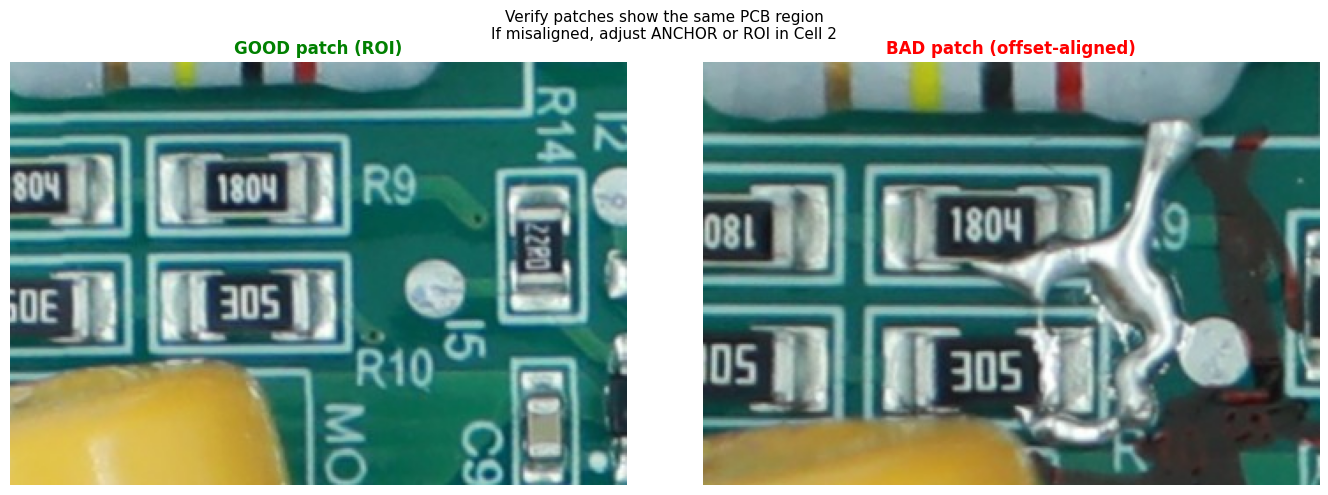

In [6]:
# Extract ROI from good image
gp = good[ROI_Y1:ROI_Y2, ROI_X1:ROI_X2]

# Extract corresponding region from bad image using offset
bx1 = max(0, ROI_X1 + dx)
bx2 = min(bad.shape[1], ROI_X2 + dx)
by1 = max(0, ROI_Y1 + dy)
by2 = min(bad.shape[0], ROI_Y2 + dy)
bp  = bad[by1:by2, bx1:bx2]
bp  = cv2.resize(bp, (gp.shape[1], gp.shape[0]))

print(f'Patch size: {gp.shape[1]}x{gp.shape[0]}')

fig, axes = plt.subplots(1,2,figsize=(14,5))
axes[0].imshow(cv2.cvtColor(gp, cv2.COLOR_BGR2RGB))
axes[0].set_title('GOOD patch (ROI)', color='green', fontweight='bold', fontsize=12)
axes[1].imshow(cv2.cvtColor(bp, cv2.COLOR_BGR2RGB))
axes[1].set_title('BAD patch (offset-aligned)', color='red', fontweight='bold', fontsize=12)
for ax in axes: ax.axis('off')
plt.suptitle('Verify patches show the same PCB region\n'
             'If misaligned, adjust ANCHOR or ROI in Cell 2', fontsize=11)
plt.tight_layout()
plt.show()

In [7]:
def hist_match(src, ref):
    """Match brightness/contrast of src to ref."""
    out = np.zeros_like(src)
    for c in range(3):
        s_h,_ = np.histogram(src[:,:,c].ravel(), 256, [0,256])
        r_h,_ = np.histogram(ref[:,:,c].ravel(), 256, [0,256])
        s_cdf = s_h.cumsum()/s_h.sum()
        r_cdf = r_h.cumsum()/r_h.sum()
        lut   = np.zeros(256, dtype=np.uint8)
        ri    = 0
        for si in range(256):
            while ri < 255 and r_cdf[ri] < s_cdf[si]: ri += 1
            lut[si] = ri
        out[:,:,c] = lut[src[:,:,c]]
    return out

# Match brightness
bp_m = hist_match(bp, gp)
gp_g = cv2.cvtColor(gp,   cv2.COLOR_BGR2GRAY)
bp_g = cv2.cvtColor(bp_m, cv2.COLOR_BGR2GRAY)

# SSIM score
score, _ = ssim(gp_g, bp_g, full=True)

# Directional subtraction: regions where BAD is brighter than GOOD
# = extra solder material that wasn't there before
extra_bright = cv2.subtract(bp_g, gp_g)

# Absolute diff for full picture
diff_abs = cv2.absdiff(gp_g, bp_g)

# Threshold solder-specific map
_, thresh = cv2.threshold(extra_bright, BRIGHT_THRESHOLD, 255, cv2.THRESH_BINARY)
k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(5,5))
thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN,   k, iterations=1)
thresh = cv2.morphologyEx(thresh, cv2.MORPH_DILATE, k, iterations=2)

# Find contours
cnts, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
boxes   = [(cv2.boundingRect(c), cv2.contourArea(c))
           for c in cnts if cv2.contourArea(c) > MIN_SOLDER_AREA]
boxes.sort(key=lambda x: -x[1])

# Verdict
verdict = 'DEFECTIVE — SOLDER SPREAD' \
    if (score < SSIM_THRESHOLD or len(boxes) > 0) else 'GOOD'

print(f'SSIM score           : {score:.3f}  (threshold={SSIM_THRESHOLD})')
print(f'Solder regions found : {len(boxes)}')
print(f'Verdict              : {verdict}')
print()
for i,((x,y,w,h),area) in enumerate(boxes[:5]):
    print(f'  Region {i+1}: x={x} y={y} w={w} h={h}  area={area:.0f} px²')

SSIM score           : 0.156  (threshold=0.5)
Solder regions found : 12
Verdict              : DEFECTIVE — SOLDER SPREAD

  Region 1: x=87 y=0 w=227 h=240  area=24526 px²
  Region 2: x=36 y=54 w=49 h=77  area=2110 px²
  Region 3: x=78 y=0 w=84 h=31  area=1868 px²
  Region 4: x=36 y=134 w=49 h=62  area=1778 px²
  Region 5: x=0 y=0 w=76 h=32  area=1469 px²


Anchor confidence: 0.521  offset: dx=25 dy=9
All regions    : 20
Median area    : 438 px²
After filter   : 1 region(s)
SSIM           : 0.156  (threshold=0.5)
Verdict        : DEFECTIVE — SOLDER SPREAD
Defect region  : x=87 y=0 w=227 h=240  area=24526 px²


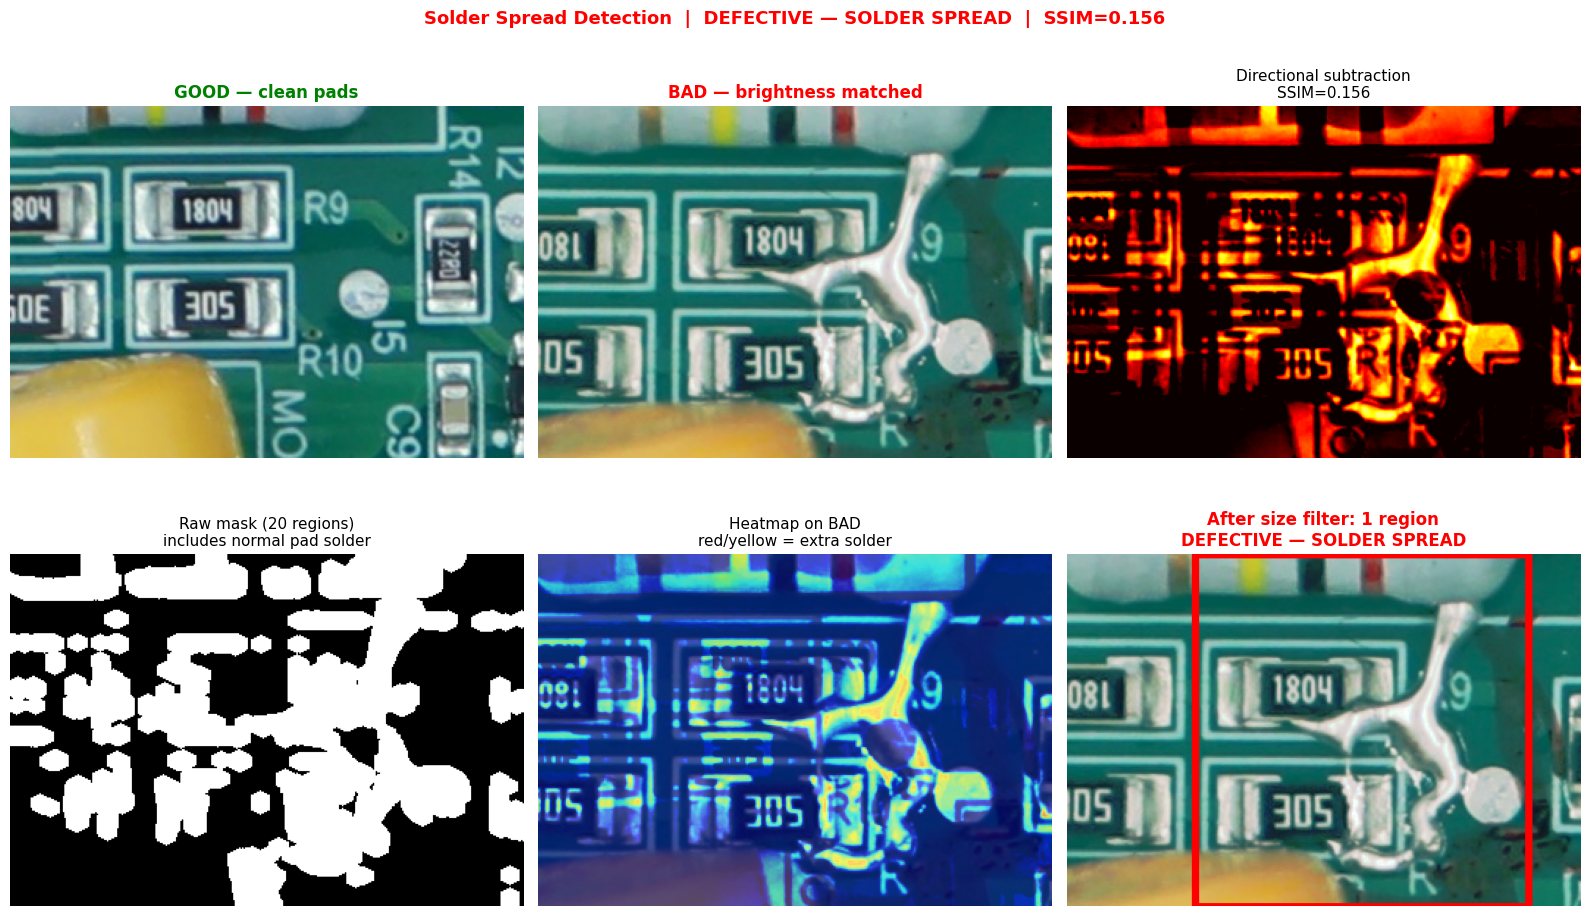

Saved: /kaggle/working/solder_spread_detection.png


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim

def hist_match(src, ref):
    """Match brightness/contrast of src to ref."""
    out = np.zeros_like(src)
    for c in range(3):
        s_h,_ = np.histogram(src[:,:,c].ravel(), 256, [0,256])
        r_h,_ = np.histogram(ref[:,:,c].ravel(), 256, [0,256])
        s_cdf = s_h.cumsum()/s_h.sum()
        r_cdf = r_h.cumsum()/r_h.sum()
        lut = np.zeros(256, dtype=np.uint8)
        ri = 0
        for si in range(256):
            while ri < 255 and r_cdf[ri] < s_cdf[si]: ri += 1
            lut[si] = ri
        out[:,:,c] = lut[src[:,:,c]]
    return out

good_g = cv2.cvtColor(good, cv2.COLOR_BGR2GRAY)
bad_g  = cv2.cvtColor(bad,  cv2.COLOR_BGR2GRAY)
anchor_tmpl = good_g[ANCHOR_Y1:ANCHOR_Y2, ANCHOR_X1:ANCHOR_X2]
th, tw = anchor_tmpl.shape
result = cv2.matchTemplate(bad_g, anchor_tmpl, cv2.TM_CCOEFF_NORMED)
_, conf, _, loc = cv2.minMaxLoc(result)
dx = (loc[0] + tw//2) - (ANCHOR_X1 + tw//2)
dy = (loc[1] + th//2) - (ANCHOR_Y1 + th//2)
print(f'Anchor confidence: {conf:.3f}  offset: dx={dx} dy={dy}')

gp  = good[ROI_Y1:ROI_Y2, ROI_X1:ROI_X2]
bx1 = max(0, ROI_X1+dx); bx2 = min(bad.shape[1], ROI_X2+dx)
by1 = max(0, ROI_Y1+dy); by2 = min(bad.shape[0], ROI_Y2+dy)
bp  = cv2.resize(bad[by1:by2, bx1:bx2], (gp.shape[1], gp.shape[0]))

# ── Histogram match + directional subtraction ──
bp_m  = hist_match(bp, gp)
gp_g  = cv2.cvtColor(gp,   cv2.COLOR_BGR2GRAY)
bp_g  = cv2.cvtColor(bp_m, cv2.COLOR_BGR2GRAY)
extra_bright = cv2.subtract(bp_g, gp_g)   # only regions where BAD > GOOD
score, _ = ssim(gp_g, bp_g, full=True)

# ── Threshold ──
_, thresh = cv2.threshold(extra_bright, BRIGHT_THRESHOLD, 255, cv2.THRESH_BINARY)
k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN,   k, iterations=1)
thresh = cv2.morphologyEx(thresh, cv2.MORPH_DILATE, k, iterations=2)

cnts, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
all_boxes = sorted(
    [(cv2.boundingRect(c), cv2.contourArea(c)) for c in cnts],
    key=lambda x: -x[1]
)

# Keep only regions that are large enough AND much bigger than typical pad solder.
SPREAD_MIN_AREA        = 3000   
SPREAD_RATIO_VS_MEDIAN = 5.0    
if all_boxes:
    median_area = np.median([a for _,a in all_boxes])
    defect_boxes = [
        (box, area) for box, area in all_boxes
        if area > SPREAD_MIN_AREA
        and area > median_area * SPREAD_RATIO_VS_MEDIAN
    ]
    print(f'All regions    : {len(all_boxes)}')
    print(f'Median area    : {median_area:.0f} px²')
    print(f'After filter   : {len(defect_boxes)} region(s)')
else:
    defect_boxes = []

verdict = 'DEFECTIVE — SOLDER SPREAD' \
    if (score < SSIM_THRESHOLD or len(defect_boxes) > 0) else 'GOOD'

print(f'SSIM           : {score:.3f}  (threshold={SSIM_THRESHOLD})')
print(f'Verdict        : {verdict}')
if defect_boxes:
    (x,y,w,h),area = defect_boxes[0]
    print(f'Defect region  : x={x} y={y} w={w} h={h}  area={area:.0f} px²')

# ── Annotate ──
ann = bp_m.copy()
for (x,y,w,h),area in defect_boxes:
    cv2.rectangle(ann,(x,y),(x+w,y+h),(0,0,255),3)
    cv2.putText(ann,'SOLDER SPREAD',(x, max(0,y-10)),
                cv2.FONT_HERSHEY_SIMPLEX,0.65,(0,0,255),2)

hm      = cv2.applyColorMap(extra_bright, cv2.COLORMAP_JET)
overlay = cv2.addWeighted(bp_m, 0.4, hm, 0.6, 0)

fig, axes = plt.subplots(2,3, figsize=(16,10))
axes[0,0].imshow(cv2.cvtColor(gp,   cv2.COLOR_BGR2RGB))
axes[0,0].set_title('GOOD — clean pads',
                     color='green', fontweight='bold', fontsize=12)

axes[0,1].imshow(cv2.cvtColor(bp_m, cv2.COLOR_BGR2RGB))
axes[0,1].set_title('BAD — brightness matched',
                     color='red', fontweight='bold', fontsize=12)

axes[0,2].imshow(extra_bright, cmap='hot')
axes[0,2].set_title(f'Directional subtraction\nSSIM={score:.3f}', fontsize=11)

axes[1,0].imshow(thresh, cmap='gray')
axes[1,0].set_title(f'Raw mask ({len(all_boxes)} regions)\n'
                     f'includes normal pad solder', fontsize=11)

axes[1,1].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
axes[1,1].set_title('Heatmap on BAD\nred/yellow = extra solder', fontsize=11)

axes[1,2].imshow(cv2.cvtColor(ann, cv2.COLOR_BGR2RGB))
axes[1,2].set_title(f'After size filter: {len(defect_boxes)} region\n{verdict}',
                     fontsize=12, fontweight='bold',
                     color='red' if 'DEFECTIVE' in verdict else 'green')

for ax in axes.flatten(): ax.axis('off')
plt.suptitle(
    f'Solder Spread Detection  |  {verdict}  |  SSIM={score:.3f}',
    fontsize=13, fontweight='bold',
    color='red' if 'DEFECTIVE' in verdict else 'green'
)
plt.tight_layout()
out_path = f'{OUTPUT_DIR}/solder_spread_detection.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path}')
